In [ ]:
import pandas as pd
import numpy as np
import os
from Markov_Chains.gaze_markov_model import GazeMarkovModel as MCAnalyzer
from Trial import TrialManager
from participant_gaze_data_manager import ParticipantGazeDataManager

# Creating within-corralation matrix 
## for all subjects found in the diractory

### creating a dict with all participants names by groups

In [3]:
# extract all the names and groups of the participants from os folders names:

Noam_data_path = "/Volumes/ramot/Noam_M/Results/Behavior"

participants = {"HC": [], "pwMS": []}
for group in ["HC", "pwMS"]:
    group_path = os.path.join(Noam_data_path, group)
    if os.path.isdir(group_path):
        for p_name in os.listdir(group_path):
            if os.path.isdir(os.path.join(group_path, p_name, "SDMT")):
                participants[group].append(p_name)

print(participants)

{'HC': ['OY974', 'KH736', 'PD922', 'LE750', 'LT157', 'TS512', 'EE050', 'FZ767', 'RO755', 'CN205', 'CS653', 'PG184', 'KT158', 'SA803', 'ZM425', 'VA784', 'RL823', 'YR187', 'DM242', 'YR573', 'VA725', 'SN975', 'SE304', 'LD965', 'SS408', 'KS856', 'KS689', 'KN566', 'LY082', 'PO515', 'NN111', 'BL238', 'BY165', 'AN814', 'HA186', 'KS130', 'PA981', 'PR454', 'AS778', 'BO921', 'GS739', 'YO399', 'SO754', 'PT914', 'GI702', 'AM367', 'DD328', 'LT752'], 'pwMS': ['GM552', 'ZA720', 'BR984', 'NG368', 'BR876', 'CM906', 'KT360', 'TM906', 'FS368', 'CN482', 'BA848', 'SM964', 'BV329', 'KD818', 'BR152', 'ZE374', 'ZS065', 'RV501', 'CR991', 'GO777', 'GT239', 'BY832', 'RD707', 'DN859', 'KM269', 'CA984', 'MK547', 'SR081', 'AS038', 'TS243', 'PA356', 'ED186', 'AG562', 'LM308', 'BA755', 'YS875', 'BN201', 'ZN290', 'NK494', 'ZL881', 'BD783', 'SI585', 'ST149', 'GR333', 'RS101', 'AA562', 'PM104', 'II318', 'KH607', 'OM743', 'FF688', 'DI192', 'KI485', 'KO801', 'ZC673', 'LS388', 'ST888', 'AP344', 'MI829', 'YN187', 'LA627', '

In [7]:
#count number of participants in each goup
from enum import unique


for group, names in participants.items():
    print(f"Number of participants in group {group}: {len(names)}")

Number of participants in group HC: 48
Number of participants in group pwMS: 75


In [8]:
print(48+75)

123


### creating markov matrices for all of them

In [ ]:
from constants import KEY_STRIKE_SCORE


markov_matrix_path = "/Volumes/ramot/Noam_M/preliminary_results/no repeats/markov_matrices"
matrices = {group: {} for group in participants.keys()}
panels = ["0", "i1", "l4", "a3", "a5", "l3"]
for group in participants.keys():
    for p_name in participants[group]:
        matrices[group][p_name] = {}
        for panel in panels:
            try:

                participant_data = ParticipantGazeDataManager(p_name, Noam_data_path , "SDMT", group)
                # score = participant_data.matched_data[panel][KEY_STRIKE_SCORE]

                trial_maneger = TrialManager(participant_data, panel)
                mc_analyzer = MCAnalyzer(trial_maneger.trials)
                transition_prob_table = mc_analyzer.get_transition_probabilities(clean = True)
                # IF ALL THE MATRIX IS 0 in all cells, then i dont want to save it even
                if transition_prob_table.values.sum() <= 1:
                    print(f"Skipping Markov matrix for {p_name} panel {panel} due to all zero values.")
                    continue

                matrices[group][p_name][panel] = (transition_prob_table, score)

                file_name = f"markov_matrix_{p_name}_panel_{panel}.csv"
                os.makedirs(os.path.join(markov_matrix_path, group, p_name), exist_ok = True)
                output_path = os.path.join(markov_matrix_path, group, p_name, file_name)

                transition_prob_table.to_csv(output_path)
                print(f"Saved Markov matrix for {p_name} panel {panel} at {output_path}")
            except Exception as e:
                print(f"Error processing {p_name} panel {panel}: {e}")

In [ ]:
#after having the saved matrices - create the dictionary matrices[group][p_name][panel] = (transition_prob_table, score)



### creating correlation matrices for all of them
#### each one has one matrix

In [78]:
#--------------------------------------------------------
#      WITHIN SUBJECT CORRELATION MATRICES
#--------------------------------------------------------

# corr_within_matrices_path = "/Volumes/ramot/Noam_M/preliminary_results/correlation_matrices_within_subject"
corr_within_matrices_path = "/Volumes/ramot/Noam_M/preliminary_results/new/correlation_matrices_within_subject"

correlation_matrices = {group: {} for group in participants.keys()}

for group in participants.keys():
    for p_name in participants[group]:

        if p_name not in matrices[group].keys() or len(matrices[group][p_name].keys()) == 0:
            print(f"No markov matrices for participant {p_name} in group {group}, skipping.")
            continue

        corr_df = pd.DataFrame(np.nan, index=panels, columns=panels)
        participant_mats = matrices[group][p_name]

        for p_i in panels:
            for p_j in panels:

                # Check existence
                if p_i not in participant_mats or p_j not in participant_mats:
                    continue

                try:
                    mat_i = participant_mats[p_i]
                    mat_j = participant_mats[p_j]

                    # Could fail if matrices are wrong shape, all-NaN, etc.
                    flat_i = mat_i.values.flatten()
                    flat_j = mat_j.values.flatten()
                    if flat_i.sum() <= 1 or flat_j.sum() <= 1:
                        print(f"[WARNING] {group} → {p_name} → panels ({p_i}, {p_j}): One of the matrices is all zeros, skipping correlation.")
                        continue

                    corr_value = np.corrcoef(flat_i, flat_j)[0, 1]
                    corr_df.loc[p_i, p_j] = corr_value

                except Exception as e:
                    print(f"[ERROR] {group} → {p_name} → panels ({p_i}, {p_j}): {e}")
                    # leave NaN

        # Save results
        correlation_matrices[group][p_name] = corr_df

        os.makedirs(os.path.join(corr_within_matrices_path, group), exist_ok=True)
        file_name = f"corr_matrix_between_all_panels_{p_name}.csv"
        output_path = os.path.join(corr_within_matrices_path, group, file_name)

        try:
            corr_df.to_csv(output_path)
            print(f"Saved correlation matrix for {p_name} at {output_path}")
        except Exception as e:
            print(f"[ERROR SAVING] Could not save file for {p_name}: {e}")

Saved correlation matrix for OY974 at /Volumes/ramot/Noam_M/preliminary_results/new/correlation_matrices_within_subject/HC/corr_matrix_between_all_panels_OY974.csv
Saved correlation matrix for KH736 at /Volumes/ramot/Noam_M/preliminary_results/new/correlation_matrices_within_subject/HC/corr_matrix_between_all_panels_KH736.csv
Saved correlation matrix for PD922 at /Volumes/ramot/Noam_M/preliminary_results/new/correlation_matrices_within_subject/HC/corr_matrix_between_all_panels_PD922.csv
No markov matrices for participant LE750 in group HC, skipping.
No markov matrices for participant LT157 in group HC, skipping.
Saved correlation matrix for TS512 at /Volumes/ramot/Noam_M/preliminary_results/new/correlation_matrices_within_subject/HC/corr_matrix_between_all_panels_TS512.csv
No markov matrices for participant EE050 in group HC, skipping.
No markov matrices for participant FZ767 in group HC, skipping.
Saved correlation matrix for RO755 at /Volumes/ramot/Noam_M/preliminary_results/new/corr

### creating summery tables for each group
#### idx is participants names and row is all their corralation values

In [ ]:

corr_vlaues = {group: {} for group in participants.keys()}

for group in correlation_matrices.keys():
    for p_name, corr_df in correlation_matrices[group].items():
        # Extract upper triangle
        indices = np.triu_indices_from(corr_df.values, k=1)
        vals = [v for v in corr_df.values[indices] if not np.isnan(v)]
        corr_vlaues[group][p_name] = vals
    #save in 2 tables
    try:
        corr_values_df = pd.DataFrame.from_dict(corr_vlaues[group], orient='index')
        summery_tables_path = os.path.join(corr_within_matrices_path, "summery_tables")
        os.makedirs(summery_tables_path, exist_ok=True)
        output_path = os.path.join(summery_tables_path, f"corr_values_{group}.csv")
        corr_values_df.to_csv(output_path)
        print(f"Saved summary correlation values table for group {group} at {output_path}")
    except Exception as e:
        print(f"[ERROR SAVING SUMMARY] Could not create summary table for group {group}: {e}")
        continue


# plot of only  test subjects
## we can see that the within subject correlation is very high

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up color palettes
hc_colors = sns.color_palette("Blues", n_colors=len(corr_vlaues["HC"]))
ms_colors = sns.color_palette("Reds", n_colors=len(corr_vlaues["pwMS"]))

plt.figure(figsize=(12, 6))

# X-axis offset for scatter
x_offset = 0

# Plot HC participants
for idx, (p_name, vals) in enumerate(corr_vlaues["HC"].items()):
    vals = np.array(vals)
    # Scatter points for this participant
    plt.scatter(np.full_like(vals, x_offset), vals, color=hc_colors[idx], alpha=0.6, label=p_name)
    # Mean and SD
    mean_val = np.nanmean(vals)
    sd_val = np.nanstd(vals)
    plt.errorbar(x_offset, mean_val, yerr=sd_val, fmt='o', color='k', capsize=5)
    x_offset += 1

# Plot MS participants
for idx, (p_name, vals) in enumerate(corr_vlaues["pwMS"].items()):
    vals = np.array(vals)
    plt.scatter(np.full_like(vals, x_offset), vals, color=ms_colors[idx], alpha=0.6, label=p_name)
    mean_val = np.nanmean(vals)
    sd_val = np.nanstd(vals)
    plt.errorbar(x_offset, mean_val, yerr=sd_val, fmt='o', color='k', capsize=5)
    x_offset += 1

plt.xticks(range(x_offset), list(corr_vlaues["HC"].keys()) + list(corr_vlaues["pwMS"].keys()), rotation=45)
plt.ylabel("Correlation (r) values")
plt.title("Within-participant panel correlation values")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Participants")
plt.tight_layout()
plt.show()


## between subject and panel correlation


In [ ]:
#--------------------------------------------------------
#      create matrices dictionary from csv files
#--------------------------------------------------------

import os
import pandas as pd
from constants import KEY_STRIKE_SCORE

markov_matrix_path = "/Volumes/ramot/Noam_M/preliminary_results/no repeats/markov_matrices"
panels = ["0", "i1", "l4", "a3", "a5", "l3"]

# Create empty matrices structure
matrices = {group: {} for group in participants.keys()}

for group in participants.keys():
    group_dir = os.path.join(markov_matrix_path, group)
    if not os.path.isdir(group_dir):
        print(f"Group directory missing: {group_dir}")
        continue
    
    for p_name in participants[group]:
        p_dir = os.path.join(group_dir, p_name)
        if not os.path.isdir(p_dir):
            print(f"No directory for participant {p_name} in group {group}")
            continue
        
        matrices[group][p_name] = {}
        
        # For each panel, try to load CSV
        for panel in panels:
            file_name = f"markov_matrix_{p_name}_panel_{panel}.csv"
            file_path = os.path.join(p_dir, file_name)
            
            if not os.path.isfile(file_path):
                print(f"No saved matrix for this panel {panel} of participant {p_name}, skipping.")
                continue
            
            try:
                # Load transition matrix
                transition_prob_table = pd.read_csv(file_path, index_col=0)
                
                # Extract the score (rebuild through the data manager)
                score = participant_data.matched_data[panel][KEY_STRIKE_SCORE]
                # Save into matrices
                matrices[group][p_name][panel] = transition_prob_table
            
            except Exception as e:
                print(f"Error loading file {file_path}: {e}")


In [ ]:
#--------------------------------------------------------
#      BETWEEN SUBJECT CORRELATION MATRICES
#--------------------------------------------------------
panels = ["0", "i1", "l4", "a3", "a5", "l3"]
# corr_between_matrices_path = "/Volumes/ramot/Noam_M/preliminary_results/correlation_matrices_between_subject"
corr_between_matrices_path = "/Volumes/ramot/Noam_M/preliminary_results/no repeats/correlation_matrices_between_subject"
import numpy as np
import pandas as pd
import os

# Flatten all participant-panel pairs into a single list
all_pairs = [
    (group, p_name, panel)
    for group in participants.keys()
    for p_name in participants[group]
    for panel in panels
    if panel in matrices.get(group, {}).get(p_name, {})  # only keep existing matrices
]

# Create a DataFrame filled with NaNs
index_tuples = [f"({p_name}, {panel})" for _, p_name, panel in all_pairs]
corr_matrix = pd.DataFrame(np.nan, index=index_tuples, columns=index_tuples)

# Loop over upper triangle only
for i in range(len(all_pairs)):
    group1, p_name1, panel1 = all_pairs[i]
    m1 = matrices[group1][p_name1][panel1]
    flat_1 = m1.values.flatten()

    for j in range(i, len(all_pairs)):
        group2, p_name2, panel2 = all_pairs[j]
        if p_name1 == p_name2:
            continue
        if panel2 not in matrices[group2][p_name2]:
            continue
        m2 = matrices[group2][p_name2][panel2]
        flat_2 = m2.values.flatten()
        # Skip if any matrix is all zeros
        if flat_1.sum() <= 1 or flat_2.sum() <= 1:
            continue

        try:
            corr_value = np.corrcoef(flat_1, flat_2)[0, 1]
            corr_matrix.loc[f"({p_name1}, {panel1})", f"({p_name2}, {panel2})"] = corr_value
            corr_matrix.loc[f"({p_name2}, {panel2})", f"({p_name1}, {panel1})"] = corr_value  # fill symmetric cell
        except Exception as e:
            print(f"Error computing correlation {p_name1}-{panel1} vs {p_name2}-{panel2}: {e}")
            continue

# Save
os.makedirs(corr_between_matrices_path, exist_ok=True)
output_path = os.path.join(corr_between_matrices_path, "corr_matrix_between_all_participants_all_panels.csv")
corr_matrix.to_csv(output_path)
print(f"Saved correlation matrix at {output_path}")

In [18]:
# ---------------------------------------------------------------------------------------------
# --------------------------------- IF READ FROM FILE  ----------------------------------------
# ---------------------------------------------------------------------------------------------

######     BETWEEN SUBJECT CORRELATION MATRICES - READ FROM FILE    ######
with_repeats_bool = True
if with_repeats_bool:
    folder_name = "with repeats"
else:
    folder_name = "no repeats"

corr_between_matrices_path = f"/Volumes/ramot/Noam_M/preliminary_results/{folder_name}/correlation_matrices_between_subject"
output_path = os.path.join(corr_between_matrices_path, "corr_matrix_between_all_participants_all_panels.csv")
corr_matrix = pd.read_csv(output_path, index_col=0)




######      WITHIN SUBJECT CORRELATION MATRICES - READ FROM FILE     ######

corr_within_matrices_path = f"/Volumes/ramot/Noam_M/preliminary_results/{folder_name}/correlation_matrices_within_subject"
correlation_matrices = []
for group in participants.keys():
    for p_name in participants[group]:
        try:
            file_name = f"corr_matrix_between_all_panels_{p_name}.csv"
            file_path = os.path.join(corr_within_matrices_path, group, file_name)
            corr_df = pd.read_csv(file_path, index_col=0)
            correlation_matrices.append((group, p_name, corr_df))
        except Exception as e:
            print(f"Error loading correlation matrix for {p_name} in group {group}: {e}")
            continue


Error loading correlation matrix for LE750 in group HC: [Errno 2] No such file or directory: '/Volumes/ramot/Noam_M/preliminary_results/with repeats/correlation_matrices_within_subject/HC/corr_matrix_between_all_panels_LE750.csv'
Error loading correlation matrix for LT157 in group HC: [Errno 2] No such file or directory: '/Volumes/ramot/Noam_M/preliminary_results/with repeats/correlation_matrices_within_subject/HC/corr_matrix_between_all_panels_LT157.csv'
Error loading correlation matrix for EE050 in group HC: [Errno 2] No such file or directory: '/Volumes/ramot/Noam_M/preliminary_results/with repeats/correlation_matrices_within_subject/HC/corr_matrix_between_all_panels_EE050.csv'
Error loading correlation matrix for FZ767 in group HC: [Errno 2] No such file or directory: '/Volumes/ramot/Noam_M/preliminary_results/with repeats/correlation_matrices_within_subject/HC/corr_matrix_between_all_panels_FZ767.csv'
Error loading correlation matrix for KT158 in group HC: [Errno 2] No such file o

In [19]:
# in corr_matrix change all correlations between different participants on the same panel to Nan
for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        row_label = corr_matrix.index[i]
        col_label = corr_matrix.columns[j]
        # Extract participant names and panels
        p_name_row, panel_row = row_label.strip("()").split(", ")
        p_name_col, panel_col = col_label.strip("()").split(", ")
        # If same participant and same panel, set to NaN
        if panel_row == panel_col:
            corr_matrix.iat[i, j] = np.nan


## Violin Plot

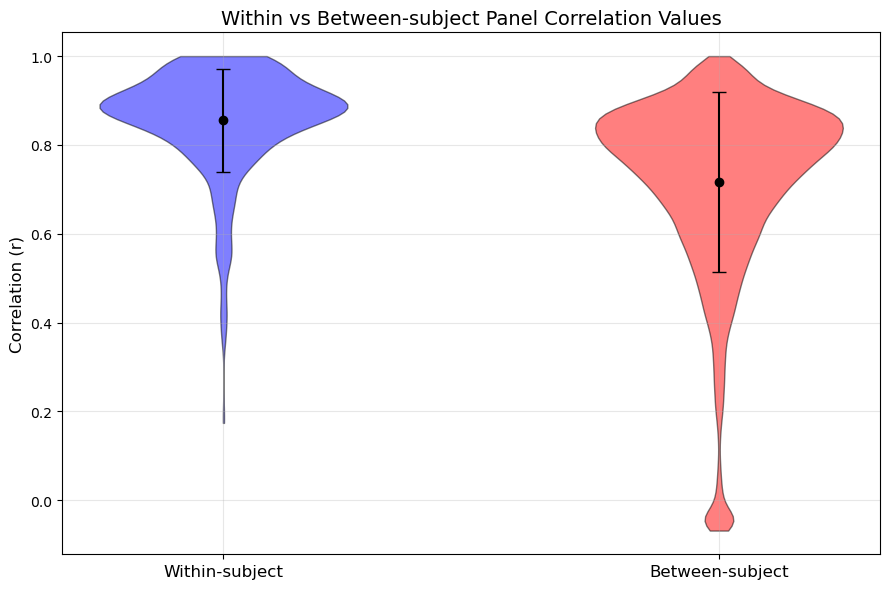

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# --- Compute values as before ---
# Between-subject correlations:
indices = np.triu_indices_from(corr_matrix.values, k=1)
mixed_corr = [v for v in corr_matrix.values[indices] if not np.isnan(v)]

# Within-subject correlations:
within_vals = []
for group,p_name, corr_df in correlation_matrices:
    indices = np.triu_indices_from(corr_df.values, k=1)
    vals = [v for v in corr_df.values[indices] if not np.isnan(v)]
    within_vals.extend(vals)

# --- Create violin plot ---
plt.figure(figsize=(9, 6))

data = [within_vals, mixed_corr]

parts = plt.violinplot(data,
                       showmeans=False,
                       showextrema=False,
                       showmedians=False)

# Set violin colors manually
for i, pc in enumerate(parts['bodies']):
    if i == 0:
        pc.set_facecolor('blue')
    else:
        pc.set_facecolor('red')
    pc.set_edgecolor('black')
    pc.set_alpha(0.5)

# Add mean + SD as points with error bars
means = [np.nanmean(within_vals), np.nanmean(mixed_corr)]
sds   = [np.nanstd(within_vals),  np.nanstd(mixed_corr)]

plt.errorbar([1, 2], means, yerr=sds, fmt='o', color='black', capsize=5, label="Mean ± SD")

# Formatting
plt.xticks([1, 2], ['Within-subject', 'Between-subject'], fontsize=12)
plt.ylabel("Correlation (r)", fontsize=12)
plt.title("Within vs Between-subject Panel Correlation Values", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

In [23]:
len(within_vals), len(mixed_corr)

(1035, 79114)

In [24]:
# t-test for both groups
from scipy import stats
t_stat, p_value = stats.ttest_ind(within_vals, mixed_corr, nan_policy='omit')
print(f"T-test results: t-statistic = {t_stat}, p-value = {p_value}")
print(f"p val is significant: {p_value < 0.05}")

T-test results: t-statistic = 21.867912744507876, p-value = 1.071652211266164e-105
p val is significant: True


## Extracting performance score for each participant and panel

In [92]:
import os
import re

Noam_data_path = "/Volumes/ramot/Noam_M/Results/Behavior"
scores_dict = {"HC": {}, "pwMS": {}}

for group in scores_dict.keys():
    group_path = os.path.join(Noam_data_path, group)
    if os.path.isdir(group_path):
        for p_name in os.listdir(group_path):
            sdmt_path = os.path.join(group_path, p_name, "SDMT")
            if os.path.isdir(sdmt_path):
                scores_dict[group][p_name] = {}
                
                for fname in os.listdir(sdmt_path):
                    if fname.endswith(".wav"):
                        # Extract panel: between "img_test_" and "_strikes"
                        panel_match = re.search(r"img_test_(.+?)_strikes", fname)
                        score_match = re.search(r"_strikes_(\d+)", fname)
                        if panel_match and score_match:
                            panel = panel_match.group(1)
                            score = int(score_match.group(1))
                            scores_dict[group][p_name][panel] = score

print(scores_dict)

{'HC': {}, 'pwMS': {}}


In [ ]:
from Markov_Chains.pareto import ParetoFrontAnalyzer
analyzer = ParetoFrontAnalyzer(n_archetypes=3, with_repeats = False)
scores = [scores_dict[group][p_name][panel.upper()] for group, p_name, panel in analyzer.metadata]
cluster_labels = analyzer.kmeans_clustering(lables=scores , n_clusters=6, save_prefix="kmeans")

Saved PC scatter plots with prefix /Volumes/ramot/Noam_M/preliminary_results/pareto_analysis/no repeats
Saved PC scatter plots with prefix /Volumes/ramot/Noam_M/preliminary_results/pareto_analysis/no repeats


# TEST for MarkovDAtaManager Class

In [ ]:
import os
import re
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from Markov_Chains.MCAnalyzer import MCAnalyzer
from Trial import TrialManager
from participant_gaze_data_manager import ParticipantGazeDataManager


PANELS = ["0", "i1", "l4", "a3", "a5", "l3"]



# ------------------------------------------------------------
#                     ParticipantMarkov
# ------------------------------------------------------------

class ParticipantMarkov:
    """
    Stores all Markov matrices and scores for a single participant.

    Attributes
    ----------
    name : str
        Participant ID
    group : str
        'HC' or 'pwMS'
    matrices : dict
        panel → pd.DataFrame of transition probabilities
    scores : dict
        panel → strike score
    """


    def __init__(self, name, group):
        self.name = name
        self.group = group
        self.matrices = {}
        self.scores = {}

    def add_matrix(self, panel, matrix):
        """Store a Markov transition matrix."""
        self.matrices[panel] = matrix

    def add_score(self, panel, score):
        """Store behavioral score."""
        self.scores[panel] = score

    def flatten_matrix(self, panel):
        """Return a flattened numpy vector of a panel matrix."""
        if panel not in self.matrices:
            return None
        return self.matrices[panel].values.flatten()

    def within_correlations(self, panels = PANELS):
        """
        Compute correlations between all panel matrices for this participant.
        Returns an NxN DataFrame.
        """
        corr_df = pd.DataFrame(np.nan, index=panels, columns=panels)

        for p_i in panels:
            for p_j in panels:

                if p_i not in self.matrices or p_j not in self.matrices:
                    continue
                if p_i == p_j:
                    continue

                v1 = self.flatten_matrix(p_i)
                v2 = self.flatten_matrix(p_j)

                if v1 is None or v2 is None:
                    continue
                if v1.sum() <= 1 or v2.sum() <= 1:
                    continue

                corr_df.loc[p_i, p_j] = np.corrcoef(v1, v2)[0, 1]

        return corr_df


# ------------------------------------------------------------
#                     CorrelationManager
# ------------------------------------------------------------

class CorrelationManager:
    @staticmethod
    def compute_between(participant_list: list[ParticipantMarkov], panels = PANELS):
        """
        Compute correlations between *different* participants across all panels.
        Returns a giant (p,p)-matrix.
        """
        # Build index
        index_labels = []
        flat_vectors = {}

        for p in participant_list:
            for panel in panels:
                if panel in p.matrices:
                    key = f"({p.group}, {p.name}, {panel})"
                    index_labels.append(key)
                    flat_vectors[key] = p.flatten_matrix(panel)

        # Create empty DataFrame
        corr_df = pd.DataFrame(np.nan, index=index_labels, columns=index_labels)

        # Loop through pairs
        for i, key1 in enumerate(index_labels):
            v1 = flat_vectors[key1]

            for j, key2 in enumerate(index_labels[i:], start=i):
                v2 = flat_vectors[key2]

                # Skip same participant
                group1, p1, panel1 = key1.split(",")
                group2, p2, panel2 = key2.split(",")
                if p1 == p2 or panel1 == panel2:
                    continue

                if v1.sum() <= 1 or v2.sum() <= 1:
                    continue

                corr = np.corrcoef(v1, v2)[0, 1]
                corr_df.loc[key1, key2] = corr
                corr_df.loc[key2, key1] = corr

        return corr_df


# ------------------------------------------------------------
#                     MarkovDataManager
# ------------------------------------------------------------

class MarkovDataManager:
    """
    Master class that loads participants, loads or computes Markov matrices,
    loads scores, and computes correlations.

    Usage:
        mdm = MarkovDataManager(root_path, matrix_path)
        mdm.load_all_data()
        df_within = mdm.get_within_subject_correlations()
        df_between = mdm.get_between_subject_correlations()
    """

    def __init__(self, behavior_path, matrix_base_path, with_repeats: bool):
        self.behavior_path = behavior_path
        self.with_repeats = with_repeats
        self.folder_name = "with repeats" if with_repeats else "no repeats"
        self.matrix_path = os.path.join(matrix_base_path, self.folder_name, "markov_matrices")

        self.panels = PANELS

        # HC → {p_name → ParticipantMarkov}
        # pwMS → {p_name → ParticipantMarkov}
        self.participants: dict[str, dict[str, ParticipantMarkov]] = {"HC": {}, "pwMS": {}} 

    # ------------------------------------------------------------
    #                 1. LOAD PARTICIPANTS NAMES
    # ------------------------------------------------------------

    def load_participant_list(self):
        for group in ["HC", "pwMS"]:
            group_path = os.path.join(self.behavior_path, group)
            if not os.path.isdir(group_path):
                continue

            for p_name in os.listdir(group_path):
                sdmt_path = os.path.join(group_path, p_name, "SDMT")
                if os.path.isdir(sdmt_path):
                    self.participants[group][p_name] = ParticipantMarkov(p_name, group)

    # ------------------------------------------------------------
    #                     2. LOAD SCORES
    # ------------------------------------------------------------

    @staticmethod
    def extract_scores_from_audio_filenames(sdmt_dir):
        scores = {}
        for fname in os.listdir(sdmt_dir):
            if fname.endswith(".wav"):
                panel_match = re.search(r"img_test_(.+?)_strikes", fname)
                score_match = re.search(r"_strikes_(\d+)", fname)
                if panel_match and score_match:
                    panel = panel_match.group(1)
                    score = int(score_match.group(1))
                    scores[panel] = score
        return scores

    def load_scores(self):
        for group, participants in self.participants.items():
            for p_name, obj in participants.items():
                sdmt_dir = os.path.join(self.behavior_path, group, p_name, "SDMT")
                if not os.path.isdir(sdmt_dir):
                    continue

                scores = self.extract_scores_from_audio_filenames(sdmt_dir)
                for panel, score in scores.items():
                    obj.add_score(panel, score)

    # ------------------------------------------------------------
    #                  3. LOAD MARKOV MATRICES
    # ------------------------------------------------------------

    def load_matrices_from_disk(self):
        for group, participants in self.participants.items():
            for p_name, p_obj in participants.items():
                p_folder = os.path.join(self.matrix_path,group, p_name)
                if not os.path.isdir(p_folder):
                    print(f"[WARNING] Missing folder for {group}/{p_name}: {p_folder}")
                    continue

                for panel in self.panels:
                    csv_path = os.path.join(
                        p_folder, f"markov_matrix_{p_name}_panel_{panel}.csv"
                    )
                    if os.path.isfile(csv_path):
                        try:
                            mat = pd.read_csv(csv_path, index_col=0)
                            p_obj.add_matrix(panel, mat)
                        except Exception as e:
                            print(f"[LOAD ERROR] {csv_path}: {e}")
                            
                if len(p_obj.matrices) == 0:
                    print(f"[WARNING] No matrices loaded for {group}/{p_name}, removing participant.")
                    self.participants[group].pop(p_name)

    def load_matrices_from_raw_data(self, overwrite: bool = False, clean: bool = True):
        """
        Load raw gaze data, compute Markov matrices for each participant + panel,
        and store them exactly the same way as load_matrices_from_disk(),
        using Participant.add_matrix(panel, df).

        Parameters
        ----------
        overwrite : bool
            If True, recompute matrices even if CSV already exists.
        clean : bool
            If True, collapse repeated fixations in the same ROI.
            If False, keep repeated fixations (allowing self-transitions).
        """

        print("\n=== Loading Markov matrices from raw gaze data ===\n")

        for group, participants in self.participants.items():
            for p_name, p_obj in participants.items():

                # Directory to save CSVs
                save_dir = os.path.join(self.matrix_path, group, p_name)
                os.makedirs(save_dir, exist_ok=True)

                # Load participant raw gaze manager
                try:
                    participant_data = ParticipantGazeDataManager(
                        p_name,
                        self.behavior_path,
                        "SDMT",
                        group
                    )
                except Exception as e:
                    print(f"[ERROR] Cannot load raw data for {group}/{p_name}: {e}")
                    continue

                # Iterate over panels
                for panel in self.panels:

                    save_path = os.path.join(
                        save_dir,
                        f"markov_matrix_{p_name}_panel_{panel}.csv"
                    )

                    # Case 1: matrix already exists on disk and we don't overwrite
                    if os.path.isfile(save_path) and not overwrite:
                        try:
                            df = pd.read_csv(save_path, index_col=0)
                            p_obj.add_matrix(panel, df)  # ← ensures identical structure
                            continue
                        except Exception as e:
                            print(f"[WARNING] Corrupted CSV, recomputing: {save_path}")

                    # Case 2: compute matrix from raw gaze data
                    try:
                        trial_manager = TrialManager(participant_data, panel)
                        mc_analyzer = MCAnalyzer(trial_manager.trials)

                        transition_prob_table = mc_analyzer.get_transition_probabilities(clean=clean)

                        # Skip empty matrices
                        if transition_prob_table.values.sum() <= 1e-9:
                            print(f"[SKIP] {group}/{p_name}/{panel}: empty Markov matrix.")
                            continue

                        # Save to disk
                        transition_prob_table.to_csv(save_path)

                        # Store in Participant object (same as disk-loader)
                        p_obj.add_matrix(panel, transition_prob_table)

                        print(f"✓ Computed & saved matrix for {group}/{p_name}, panel {panel}")

                    except Exception as e:
                        print(f"[ERROR] Computing matrix for {group}/{p_name}/{panel}: {e}")
                        continue

        print("\n=== Done loading matrices from raw data ===\n")

    # ------------------------------------------------------------
    #                  4. COMPUTE CORRELATIONS
    # ------------------------------------------------------------

    def get_within_subject_correlations(self):
        results = []
        for group, participants in self.participants.items():
            for p_name, p_obj in participants.items():
                corr_df = p_obj.within_correlations()
                results.append((group, p_name, corr_df))
        return results

    def get_between_subject_correlations(self):
        all_participants = []
        for group, participants in self.participants.items():
            for p_name, p_obj in participants.items():
                all_participants.append(p_obj)

        return CorrelationManager.compute_between(all_participants, self.panels)

    # ------------------------------------------------------------
    #                     MASTER LOADER
    # ------------------------------------------------------------

    def load_all_data(self, from_scratch=False):
        print("Loading participants...")
        self.load_participant_list()

        print("Loading scores...")
        self.load_scores()

        print("Loading Markov matrices...")
        if from_scratch:
            print("Computing matrices from raw data...")
            self.load_matrices_from_raw_data(overwrite=True, clean = not self.with_repeats)  # if "overwrite" set to False it reads from disk and completes the missing matrices 
        else:
            self.load_matrices_from_disk()

        print("Done.")


In [37]:

##         TESTING THE NEW IMPLEMENTATION     ##

# ---------------------------------------------------------
# 1. Load data using the updated MarkovDataManager
# ---------------------------------------------------------

behavior_root = "/Volumes/ramot/Noam_M/Results/Behavior"
matrix_root = "/Volumes/ramot/Noam_M/preliminary_results"

# with_repeats=True → self transitions allowed
mdm = MarkovDataManager(behavior_root, matrix_root, with_repeats=True)

mdm.load_all_data(from_scratch=False)  # or True to recompute everything



Loading participants...
Loading scores...
Loading Markov matrices...
Done.


In [38]:
# ---------------------------------------------------------
# 2. Build a DataFrame for violin plot (same structure as before)
# ---------------------------------------------------------

within_corr = mdm.get_within_subject_correlations()
between_corr = mdm.get_between_subject_correlations()

In [39]:
len(within_vals), len(mixed_corr)  

(1015, 79114)

In [29]:
print(123*6*5/2)

1845.0


In [31]:
print(442*441/2)

97461.0


In [43]:
records = []

# --- Within ---
for group, p_name, corr_df in within_corr:
    # Get upper triangle indices (excluding diagonal)
    rows, cols = np.triu_indices_from(corr_df.values, k=1)

    for r, c in zip(rows, cols):
        v = corr_df.values[r, c]
        if pd.isna(v):
            continue

        panel1 = corr_df.index[r]
        panel2 = corr_df.columns[c]

        records.append({
            "type": "within",
            "group": group,
            "participant": p_name,
            "panel": f"{panel1}-{panel2}",
            "correlation": v
        })

# --- Between ---
for i in between_corr.index:
    for j in between_corr.columns:
        # Only consider upper triangle to avoid double counting
        if between_corr.index.get_loc(i) >= between_corr.columns.get_loc(j):
            continue

        v = between_corr.loc[i, j]
        if pd.isna(v):
            continue

        group1, p1, panel1 = re.match(r"\((.+?), (.+?), (.+?)\)", i).groups()
        group2, p2, panel2 = re.match(r"\((.+?), (.+?), (.+?)\)", j).groups()

        records.append({
            "type": "between",
            "group": f"{group1}-{group2}",
            "participant": f"{p1}-{p2}",
            "panel": f"{panel1}-{panel2}",
            "correlation": v
        })

df = pd.DataFrame(records)

In [41]:
df.head(-5)

""


In [42]:
# ---------------------------------------------------------
# 3. Plot violin to check consistency
# ---------------------------------------------------------

# --- Extract data from df ---
within_vals = df.loc[df['type'] == 'within', 'correlation'].values
between_vals = df.loc[df['type'] == 'between', 'correlation'].values

within_vals.shape, between_vals.shape

KeyError: 'type'

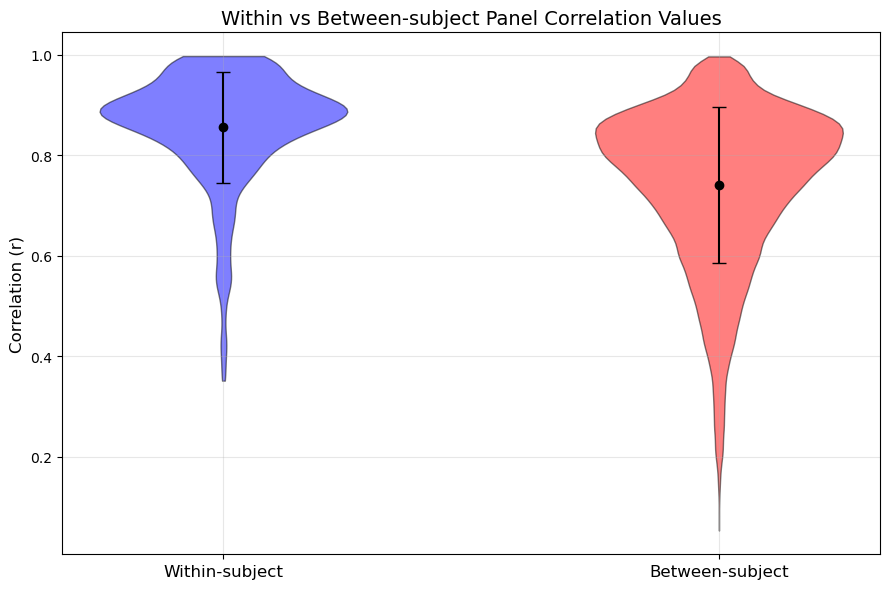

In [ ]:


data = [within_vals, between_vals]

# --- Create violin plot ---
plt.figure(figsize=(9, 6))
parts = plt.violinplot(data,
                       showmeans=False,
                       showextrema=False,
                       showmedians=False)

# Set colors
colors = ['blue', 'red']
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(0.5)

# Add mean ± SD
means = [np.nanmean(within_vals), np.nanmean(between_vals)]
sds   = [np.nanstd(within_vals), np.nanstd(between_vals)]
plt.errorbar([1, 2], means, yerr=sds, fmt='o', color='black', capsize=5, label="Mean ± SD")

# Formatting
plt.xticks([1, 2], ['Within-subject', 'Between-subject'], fontsize=12)
plt.ylabel("Correlation (r)", fontsize=12)
plt.title("Within vs Between-subject Panel Correlation Values", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()